In [1]:
import torch
import clip
from tqdm import tqdm
from PIL import Image
from torchvision.datasets import CIFAR10, CIFAR100
import torchvision.transforms as transforms
import os

import numpy as np
from sklearn.linear_model import LogisticRegression
from torch.utils.data import DataLoader

from sklearn.neighbors import KernelDensity as KD
from sklearn.kernel_ridge import KernelRidge as KR
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics.pairwise import pairwise_kernels
from sklearn.metrics import accuracy_score, roc_auc_score,confusion_matrix

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

In [2]:
def get_features(dataset):
    all_features = []
    all_labels = []
    ix = 0
    with torch.no_grad():
        # get image embeddings and labels
        for images, labels in tqdm(DataLoader(dataset, batch_size=200)):
            features = model.encode_image(images.to(device))

            all_features.append(features)
            all_labels.append(labels)

            ix += 200
    return torch.cat(all_features).cpu().numpy(), torch.cat(all_labels).cpu().numpy()

def get_text_features(dataset):
    with torch.no_grad():
        # get text embeddings
        text_inputs = torch.cat([clip.tokenize(f"a photo of a {c}") for c in dataset.classes]).to(device)
        text_features = model.encode_text(text_inputs)
    return text_features.cpu().numpy()

In [3]:
# for ARM Macs
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

In [4]:
# Load the dataset
batch_size = 200

# 10K samples
testset = CIFAR10(root='../data', train=False,
                                       download=True, transform=preprocess)


100%|██████████| 170498071/170498071 [00:16<00:00, 10413782.45it/s]


Extracting ../data/cifar-10-python.tar.gz to ../data


In [7]:
# split testset100 into validation and test
generator1 = torch.Generator().manual_seed(42)
val_data, test_data = torch.utils.data.random_split(testset, [0.5, 0.5], generator=generator1)

val_embeddings, val_labels = get_features(val_data)
test_embeddings, test_labels = get_features(test_data)

  0%|          | 0/25 [00:00<?, ?it/s]

torch.Size([200, 3, 224, 224])


  0%|          | 0/25 [00:02<?, ?it/s]


In [6]:
print(val_embeddings.shape)
print(val_labels.shape)
print(test_embeddings.shape)
print(test_labels.shape)

(5000, 512)
(5000,)
(5000, 512)
(5000,)


### Zero Shot Prediction

In [7]:
text_features = get_text_features(testset)
# prediction
val_embeddings /= torch.tensor(val_embeddings).norm(dim=-1, keepdim=True)
text_features /= torch.tensor(text_features).norm(dim=-1, keepdim=True)
similarity = torch.tensor(100.0 * val_embeddings @ text_features.T).softmax(dim=-1)
val_values, val_labels_pred = similarity.topk(1)
val_labels_pred = val_labels_pred.numpy()

/var/folders/pj/d5fd92595v35t48mf5bgyrd00000gn/T/ipykernel_42641/3576262794.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  similarity = torch.tensor(100.0 * val_embeddings @ text_features.T).softmax(dim=-1)


In [8]:
# Calculate the accuracy
correct_predictions = np.sum(val_labels_pred.squeeze() == val_labels)
total_predictions = len(val_labels)
accuracy = correct_predictions / total_predictions

# Convert accuracy to a percentage
accuracy_percentage = accuracy * 100

print("Validation Accuracy:", accuracy_percentage, "%")

Accuracy: 88.68 %


In [16]:
# prediction on test set
test_embeddings /= torch.tensor(test_embeddings).norm(dim=-1, keepdim=True)
similarity = torch.tensor(100.0 * test_embeddings @ text_features.T).softmax(dim=-1)
test_values, test_labels_pred = similarity.topk(1)
test_labels_pred = test_labels_pred.numpy()

test_correct_predictions = np.sum(test_labels_pred.squeeze() == test_labels)
total_predictions = len(test_labels)
test_accuracy = test_correct_predictions / total_predictions
# Convert accuracy to a percentage
test_accuracy_percentage = test_accuracy * 100

print("Test Accuracy:", test_accuracy_percentage, "%")

Test Accuracy: 88.92 %


/var/folders/pj/d5fd92595v35t48mf5bgyrd00000gn/T/ipykernel_42641/2484613400.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_embeddings /= torch.tensor(test_embeddings).norm(dim=-1, keepdim=True)
/var/folders/pj/d5fd92595v35t48mf5bgyrd00000gn/T/ipykernel_42641/2484613400.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  similarity = torch.tensor(100.0 * test_embeddings @ text_features.T).softmax(dim=-1)


### Train Error Predictor Using Logistic Regression with Tag

In [9]:
# get CIFAR-100 dataset labels from torchvision
testset100 = CIFAR100(root='../data', train=False,
                                       download=True, transform=preprocess)

tags = testset100.classes
tags_embeddings = get_text_features(testset100)

Files already downloaded and verified


In [30]:
# cos similarity of val_embeddings and tags_embeddings
error_features = val_embeddings @ tags_embeddings.T
# 0-1 loss
prediction_error_val = val_labels_pred.squeeze() != val_labels
# fit logistic regression 
clf = LogisticRegression(random_state=0, max_iter=1000).fit(error_features, prediction_error_val)

In [31]:
error_features_test = test_embeddings @ tags_embeddings.T
predicted_error_test = clf.predict(error_features_test)
true_error_test = test_labels_pred.squeeze() != test_labels

# Calculate the error-prediction accuracy
correct_predictions = np.sum(predicted_error_test == true_error_test)
total_predictions = len(true_error_test)
accuracy = correct_predictions / total_predictions
print("Test Error Accuracy:", accuracy * 100, "%")

Test Error Accuracy: 89.08 %


In [60]:
error_features_test = test_embeddings @ tags_embeddings.T
prob_predicted_error_test = clf.predict_proba(error_features_test)[:,1]
true_error_test = test_labels_pred.squeeze() != test_labels

In [77]:
import torch
from torch import nn
from torch.autograd import Variable

class LogisticRegression(nn.Module):
    def __init__(self, input_size):
        super(LogisticRegression, self).__init__()
        self.linear = nn.Linear(input_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(self.linear(x))

# Initialize logistic regression model
input_size = 100  # the number of embeddings
model = LogisticRegression(input_size)

# Fix the parameters of the logistic regression model
with torch.no_grad():
    fixed_parameters = clf.coef_
    model.linear.weight.copy_(torch.tensor(fixed_parameters))

# True label (0 or 1)
y_true = Variable(torch.tensor(true_error_test[:,None]).int()) # 5000 x 1

# Embeddings (phi_1(X), phi_2(X), ..., phi_N(X))
embeddings = Variable(error_features_test, requires_grad=True)  # 5000 x 100

# Forward pass to get the logistic regression output
logits = model(embeddings) # 5000 x 1

# 0/1 error (assuming 0/1 error = 0.5 * (y_pred - y_true)^2)
error = torch.sum(0.5 * torch.pow(logits - y_true, 2)) # 5000x1 -> sum to 1x1

# Backward pass to compute the gradient
error.backward()

# Access the gradient with respect to embeddings
gradient = embeddings.grad # 5000 x 100

# Print the gradient
print("Gradient with respect to embeddings:", gradient, gradient.shape)


Gradient with respect to embeddings: tensor([[-1.7653e-03,  4.4525e-03, -1.4593e-03,  ...,  5.6270e-03,
          8.0105e-04,  5.7615e-03],
        [-7.4751e-03,  1.8854e-02, -6.1792e-03,  ...,  2.3827e-02,
          3.3920e-03,  2.4397e-02],
        [ 1.5957e-04, -4.0247e-04,  1.3191e-04,  ..., -5.0864e-04,
         -7.2408e-05, -5.2079e-04],
        ...,
        [-2.8278e-02,  7.1322e-02, -2.3375e-02,  ...,  9.0136e-02,
          1.2832e-02,  9.2291e-02],
        [-3.3886e-03,  8.5467e-03, -2.8011e-03,  ...,  1.0801e-02,
          1.5376e-03,  1.1059e-02],
        [ 2.0063e-05, -5.0603e-05,  1.6585e-05,  ..., -6.3952e-05,
         -9.1041e-06, -6.5481e-05]]) torch.Size([5000, 100])


In [93]:
#largest_gradient = torch.argmax(torch.abs(gradient), dim=1) # 5000 x 1
# top K largest gradient
K = 1
largest_gradient = torch.topk(torch.abs(gradient), K, dim=1).indices # 5000 x K
error_idx = true_error_test == 1 # 5000 x 1

error_true_label = test_labels[error_idx] 
error_predicted_label = test_labels_pred[error_idx]
error_largest_gradient = largest_gradient[error_idx]
for i in range(100):
    print("true_label:", error_true_label[i], "predicted_label:", error_predicted_label[i], "top error tag", error_largest_gradient[i])

true_label: 2 predicted_label: [3] top error tag tensor([74])
true_label: 4 predicted_label: [5] top error tag tensor([74])
true_label: 7 predicted_label: [2] top error tag tensor([74])
true_label: 4 predicted_label: [7] top error tag tensor([74])
true_label: 4 predicted_label: [7] top error tag tensor([74])
true_label: 5 predicted_label: [7] top error tag tensor([74])
true_label: 9 predicted_label: [1] top error tag tensor([74])
true_label: 3 predicted_label: [5] top error tag tensor([74])
true_label: 0 predicted_label: [1] top error tag tensor([74])
true_label: 8 predicted_label: [1] top error tag tensor([74])
true_label: 4 predicted_label: [7] top error tag tensor([74])
true_label: 8 predicted_label: [0] top error tag tensor([74])
true_label: 3 predicted_label: [5] top error tag tensor([74])
true_label: 4 predicted_label: [3] top error tag tensor([74])
true_label: 4 predicted_label: [3] top error tag tensor([74])
true_label: 5 predicted_label: [2] top error tag tensor([74])
true_lab

In [85]:
print(tags[74])

shrew


Text(0, 0.5, 'Density')

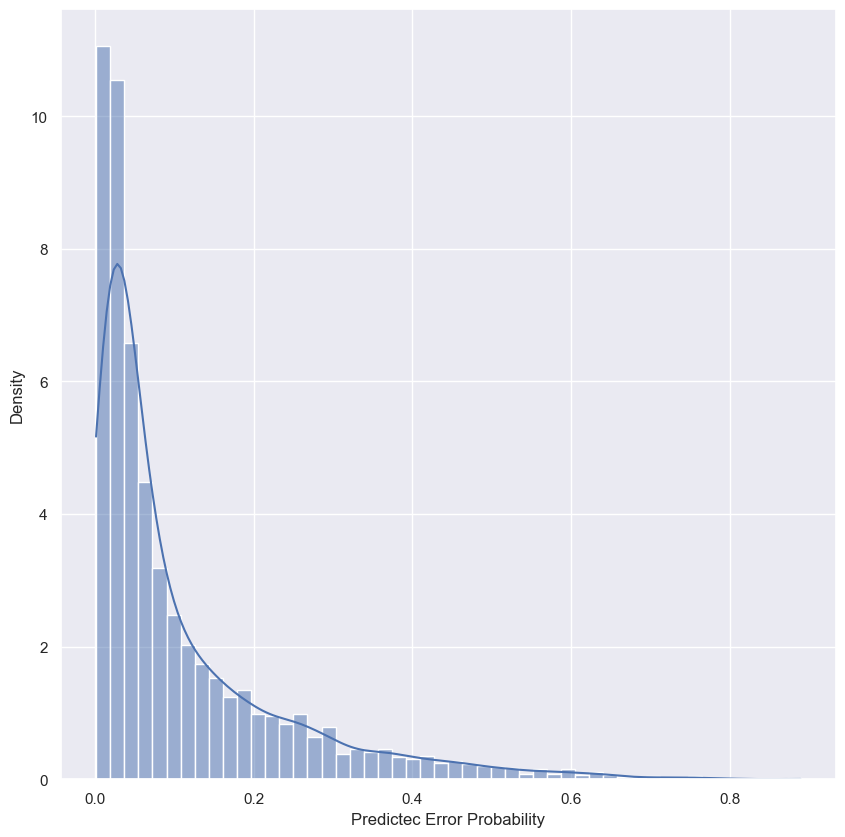

In [62]:
# plot the coefficients distribution
plt.figure(figsize=(10, 10))
sns.histplot(prob_predicted_error_test, bins=50, kde=True, stat='density')
plt.xlabel('Predictec Error Probability')
plt.ylabel('Density')

In [32]:
tn, fp, fn, tp = confusion_matrix(true_error_test, predicted_error_test).ravel()
print(tn, fp, fn, tp)

4395 51 495 59


/var/folders/pj/d5fd92595v35t48mf5bgyrd00000gn/T/ipykernel_42641/2455965444.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(coefficient)


Text(0, 0.5, 'Density')

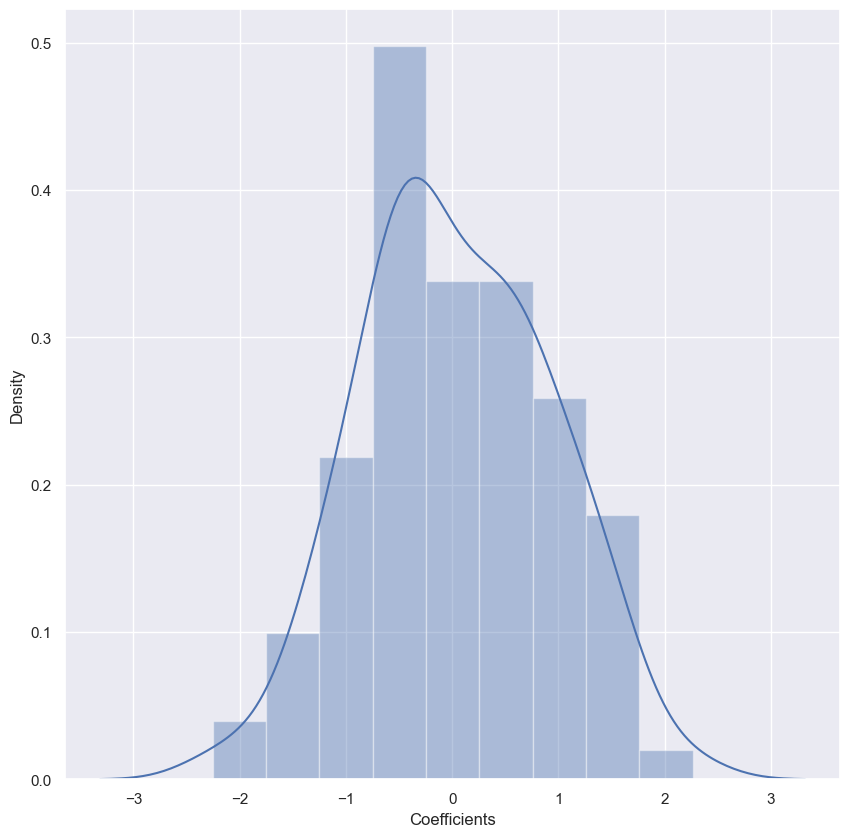

In [33]:
coefficient = clf.coef_
# plot the coefficients distribution
plt.figure(figsize=(10, 10))
sns.distplot(coefficient)
plt.xlabel('Coefficients')
plt.ylabel('Density')

In [37]:
print("Top 10 tags with highest coefficients:")
top10_tags = np.argsort(coefficient.squeeze())[-10:]
for i in reversed(top10_tags):
    print(tags[i])
    print(coefficient.squeeze()[i])


Top 10 tags with highest coefficients:
shrew
2.262720106860147
cattle
1.7525800710502517
tractor
1.6859357466259082
shark
1.5788695435848135
house
1.5163377211096314
streetcar
1.4599584860999055
orchid
1.3961190186862076
rocket
1.3330435200590682
motorcycle
1.290266364105056
worm
1.2714777042222507


In [38]:
print("Top 10 tags with lowest coefficients:")
bottom10_tags = np.argsort(coefficient.squeeze())[:10]
for i in bottom10_tags:
    print(tags[i])
    print(coefficient.squeeze()[i])

Top 10 tags with lowest coefficients:
sweet_pepper
-2.255305768794766
poppy
-1.8848971072067913
tank
-1.596206239287673
plain
-1.3736931085398683
can
-1.3177188662100996
boy
-1.2897349169309449
ray
-1.2834330747533693
squirrel
-1.23168637507022
snake
-1.1459034963869124
plate
-1.1390442410919714


### Systematic Analysis of Error using Error Function Above

## Analyze Error using MAccWitness

In [ ]:
# create witness regressor
class MAccWitness(BaseEstimator, RegressorMixin):  

    def __init__(self, gamma=1):
        """
        TODO: implement other kernels
        """
        self.gamma = gamma

    def fit(self, X, y=None):
        """
        create vanilla regressor
        """
        ix = np.abs(y)>=-0.1
        self.X_ = X[ix,:]
        self.y_ = y.reshape(len(y),1)
        self.y_ = self.y_[ix]
        self.n_ = len(self.y_)

        return self

    def predict(self, X, y=None):
        K = pairwise_kernels(X,self.X_,metric='rbf',gamma=self.gamma) # kernel matrix
        #K = pairwise_kernels(X,self.X_,metric='linear') # kernel matrix
        norm = K.sum(axis=1)
        prod = np.ravel(K@self.y_)
        return prod/norm

    def score(self, X, y=None):
        # counts number of values bigger than mean
        return(np.abs(np.corrcoef(self.predict(X),y)[0,1]))